In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import re

# NLP
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# ML & DL
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
df = pd.read_csv("/content/reviews.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


In [3]:
df = df[['content', 'score']]
df.dropna(inplace=True)

In [4]:
def score_to_sentiment(score):
    if score >= 4:
        return 1   # Positive
    elif score <= 2:
        return 0   # Negative
    else:
        return None  # Neutral

df['sentiment'] = df['score'].apply(score_to_sentiment)
df.dropna(inplace=True)

df.head()


,content,score,sentiment
0,I cannot open the app anymore,1,0.0
1,I have been begging for a refund from this app...,1,0.0
2,Very costly for the premium version (approx In...,1,0.0
3,"Used to keep me organized, but all the 2020 UP...",1,0.0
4,Dan Birthday Oct 28,1,0.0


In [76]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_content'] = df['content'].apply(clean_text)

In [6]:
X = df['cleaned_content']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [8]:
model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 192ms/step - accuracy: 0.9434 - loss: 0.1540 - val_accuracy: 0.8407 - val_loss: 0.4504
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 132ms/step - accuracy: 0.9577 - loss: 0.1220 - val_accuracy: 0.8383 - val_loss: 0.5030
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - accuracy: 0.9644 - loss: 0.1042 - val_accuracy: 0.8252 - val_loss: 0.5462
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 128ms/step - accuracy: 0.9701 - loss: 0.0900 - val_accuracy: 0.8240 - val_loss: 0.5255
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.9728 - loss: 0.0821 - val_accuracy: 0.8323 - val_loss: 0.6220


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


lstm_acc = accuracy_score(y_test, y_pred)
lstm_prec = precision_score(y_test, y_pred)
lstm_rec = recall_score(y_test, y_pred)
lstm_f1 = f1_score(y_test, y_pred)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Accuracy: 0.834840552118039
              precision    recall  f1-score   support

         0.0       0.83      0.81      0.82       975
         1.0       0.84      0.86      0.85      1126

    accuracy                           0.83      2101
   macro avg       0.83      0.83      0.83      2101
weighted avg       0.83      0.83      0.83      2101



In [13]:
###QLSTM
from tensorflow.keras.layers import Layer
import tensorflow as tf

class QuantumInspiredEmbedding(Layer):
    def __init__(self, vocab_size, embed_dim):
        super(QuantumInspiredEmbedding, self).__init__()
        self.embed_dim = embed_dim
        self.real_embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.imag_embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)

    def call(self, inputs):
        real_part = self.real_embedding(inputs)
        imag_part = self.imag_embedding(inputs)

        # Quantum-inspired magnitude and phase fusion
        magnitude = tf.sqrt(tf.square(real_part) + tf.square(imag_part))
        phase = tf.math.atan2(imag_part, real_part)

        # Concatenate magnitude & phase
        return tf.concat([magnitude, phase], axis=-1)


In [14]:
###tuned qlstm
from tensorflow.keras.callbacks import EarlyStopping


In [15]:
qlstm_model = Sequential()

qlstm_model.add(
    QuantumInspiredEmbedding(
        vocab_size=max_words,
        embed_dim=64
    )
)

qlstm_model.add(
    LSTM(
        128,   # reduced from 256
        return_sequences=False
    )
)

qlstm_model.add(Dropout(0.5))  # stronger dropout
qlstm_model.add(Dense(1, activation='sigmoid'))


In [16]:
from tensorflow.keras.optimizers import Adam

qlstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_qlstm = qlstm_model.fit(
    X_train_pad,
    y_train,
    epochs=15,           # max epochs
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 482ms/step - accuracy: 0.9080 - loss: 0.2431 - val_accuracy: 0.8419 - val_loss: 0.3978
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 33s 351ms/step - accuracy: 0.9133 - loss: 0.2228 - val_accuracy: 0.8668 - val_loss: 0.3728
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 382ms/step - accuracy: 0.9240 - loss: 0.2054 - val_accuracy: 0.8526 - val_loss: 0.3912
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 387ms/step - accuracy: 0.9319 - loss: 0.1921 - val_accuracy: 0.8490 - val_loss: 0.4034


In [22]:
y_pred_qlstm = (qlstm_model.predict(X_test_pad) > 0.5).astype("int32")

qlstm_acc = accuracy_score(y_test, y_pred_qlstm)

print("Final QLSTM Accuracy:", qlstm_acc)
print(classification_report(y_test, y_pred_qlstm))

qlstm_acc = accuracy_score(y_test, y_pred_qlstm)
qlstm_prec = precision_score(y_test, y_pred_qlstm)
qlstm_rec = recall_score(y_test, y_pred_qlstm)
qlstm_f1 = f1_score(y_test, y_pred_qlstm)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
Final QLSTM Accuracy: 0.8448357924797716
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83       975
         1.0       0.85      0.86      0.86      1126

    accuracy                           0.84      2101
   macro avg       0.84      0.84      0.84      2101
weighted avg       0.84      0.84      0.84      2101



In [23]:
lstm_acc = accuracy_score(y_test, y_pred)
qlstm_acc = accuracy_score(y_test, y_pred_qlstm)

print("Standard LSTM Accuracy:", lstm_acc)
print("Quantum-Inspired LSTM Accuracy:", qlstm_acc)


Standard LSTM Accuracy: 0.834840552118039
Quantum-Inspired LSTM Accuracy: 0.8448357924797716


In [24]:
##RDO
import random
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [54]:
def fitness_function(lstm_units, dropout_rate, learning_rate):

    model = Sequential()
    model.add(QuantumInspiredEmbedding(max_words, 64))
    model.add(LSTM(lstm_units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,              # VERY aggressive
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad,
        y_train,
        epochs=10,                # reduced
        batch_size=64,          # faster
        validation_split=0.1,   # reduced
        callbacks=[early_stop],
        verbose=0
    )

    return max(history.history['val_accuracy'])


In [52]:
population_size = 6
red_deer_population = []

for _ in range(population_size):
    deer = {
        "units": random.choice([64, 128]),     # removed 256 (too heavy)
        "dropout": round(random.uniform(0.35, 0.55), 2),
        "lr": random.choice([0.001, 0.0005])
    }
    red_deer_population.append(deer)

print("Initial Red Deer Population:")
for d in red_deer_population:
    print(d)


Initial Red Deer Population:
{'units': 128, 'dropout': 0.36, 'lr': 0.0005}
{'units': 128, 'dropout': 0.4, 'lr': 0.001}
{'units': 128, 'dropout': 0.39, 'lr': 0.0005}
{'units': 64, 'dropout': 0.37, 'lr': 0.001}
{'units': 64, 'dropout': 0.42, 'lr': 0.0005}
{'units': 128, 'dropout': 0.43, 'lr': 0.001}


In [55]:
iterations = 3
best_deer = None
best_fitness = float("-inf")

for iteration in range(iterations):
    print(f"\nIteration {iteration + 1}")

    for deer in red_deer_population:
        fitness = fitness_function(
            deer["units"],
            deer["dropout"],
            deer["lr"]
        )

        print("Deer:", deer, "| Fitness (−val_loss):", fitness)

        if fitness > best_fitness:
            best_fitness = fitness
            best_deer = deer.copy()



Iteration 1
Deer: {'units': 128, 'dropout': 0.36, 'lr': 0.0005} | Fitness (−val_loss): 0.7086801528930664
Deer: {'units': 128, 'dropout': 0.4, 'lr': 0.001} | Fitness (−val_loss): 0.6646848917007446
Deer: {'units': 128, 'dropout': 0.39, 'lr': 0.0005} | Fitness (−val_loss): 0.8382877707481384
Deer: {'units': 64, 'dropout': 0.37, 'lr': 0.001} | Fitness (−val_loss): 0.8489893078804016
Deer: {'units': 64, 'dropout': 0.42, 'lr': 0.0005} | Fitness (−val_loss): 0.6694411635398865
Deer: {'units': 128, 'dropout': 0.43, 'lr': 0.001} | Fitness (−val_loss): 0.8501783609390259

Iteration 2
Deer: {'units': 128, 'dropout': 0.36, 'lr': 0.0005} | Fitness (−val_loss): 0.840665876865387
Deer: {'units': 128, 'dropout': 0.4, 'lr': 0.001} | Fitness (−val_loss): 0.8478002548217773
Deer: {'units': 128, 'dropout': 0.39, 'lr': 0.0005} | Fitness (−val_loss): 0.8513674139976501
Deer: {'units': 64, 'dropout': 0.37, 'lr': 0.001} | Fitness (−val_loss): 0.8466112017631531
Deer: {'units': 64, 'dropout': 0.42, 'lr': 0.

In [57]:
print("\n✅ Best QLSTM Parameters Found by RDO")
print(best_deer)
print("Best Fitness Score:", best_fitness)


✅ Best QLSTM Parameters Found by RDO
{'units': 64, 'dropout': 0.37, 'lr': 0.001}
Best Fitness Score: 0.8537455201148987


In [62]:
from tensorflow.keras.callbacks import EarlyStopping

final_model = Sequential()
final_model.add(QuantumInspiredEmbedding(max_words, 64))
final_model.add(LSTM(best_deer["units"]))
final_model.add(Dropout(best_deer["dropout"]))
final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=Adam(learning_rate=best_deer["lr"]),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

history_rdo= final_model.fit(
    X_train_pad,
    y_train,
    epochs=15,                 # higher than RDO phase
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 183ms/step - accuracy: 0.6112 - loss: 0.6491 - val_accuracy: 0.6171 - val_loss: 0.6433
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.6403 - loss: 0.6319 - val_accuracy: 0.6457 - val_loss: 0.6228
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.6924 - loss: 0.5839 - val_accuracy: 0.7146 - val_loss: 0.5764
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.7175 - loss: 0.5534 - val_accuracy: 0.7598 - val_loss: 0.5242
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - accuracy: 0.7698 - loss: 0.4845 - val_accuracy: 0.8026 - val_loss: 0.4514
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.8432 - loss: 0.3684 - val_accuracy: 0.8323 - val_loss: 0.3918
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.8868 - loss: 0.2873 - val_accuracy: 0.8526 - val_loss: 0.3793
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step - accuracy: 0.9047 - loss: 0

In [63]:
y_pred_rdo = (final_model.predict(X_test_pad) > 0.5).astype("int32")

from sklearn.metrics import accuracy_score, classification_report

rdo_acc = accuracy_score(y_test, y_pred_rdo)

print("\n📌 FINAL RESULTS")
print("QLSTM + RDO Accuracy:", rdo_acc)
print(classification_report(y_test, y_pred_rdo))


rdo_acc = accuracy_score(y_test, y_pred_rdo)
rdo_prec = precision_score(y_test, y_pred_rdo)
rdo_rec = recall_score(y_test, y_pred_rdo)
rdo_f1 = f1_score(y_test, y_pred_rdo)


66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step

📌 FINAL RESULTS
QLSTM + RDO Accuracy: 0.8529271775345074
              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84       975
         1.0       0.85      0.88      0.87      1126

    accuracy                           0.85      2101
   macro avg       0.85      0.85      0.85      2101
weighted avg       0.85      0.85      0.85      2101



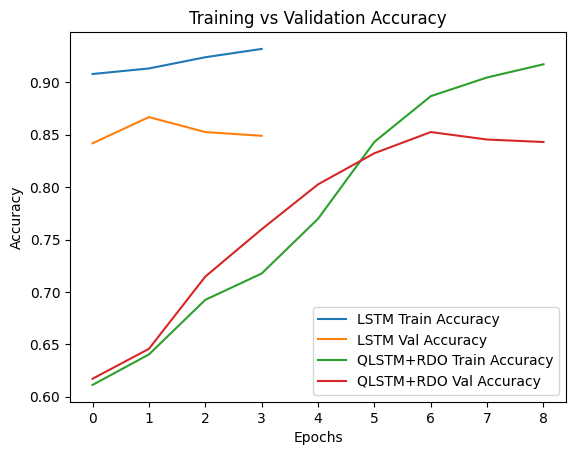

In [64]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_qlstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_qlstm.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_rdo.history['accuracy'], label='QLSTM+RDO Train Accuracy')
plt.plot(history_rdo.history['val_accuracy'], label='QLSTM+RDO Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

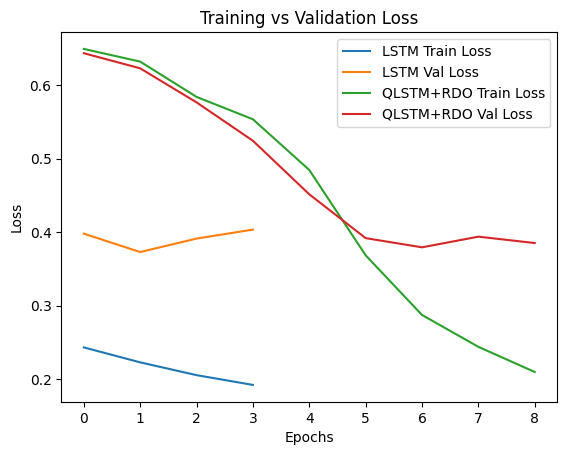

In [65]:
plt.figure()
plt.plot(history_qlstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_qlstm.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_rdo.history['loss'], label='QLSTM+RDO Train Loss')
plt.plot(history_rdo.history['val_loss'], label='QLSTM+RDO Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


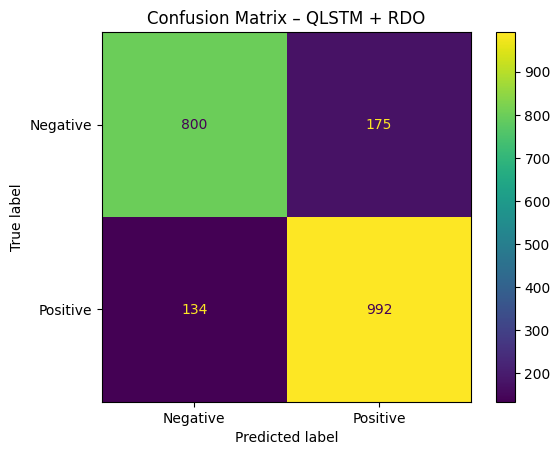

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rdo)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix – QLSTM + RDO")
plt.show()

In [68]:
#Metric Calculation Table
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ["LSTM", "QLSTM", "QLSTM + RDO"]

accuracy = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_qlstm),
    accuracy_score(y_test, y_pred_rdo)
]

precision = [
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_qlstm),
    precision_score(y_test, y_pred_rdo)
]

recall = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_qlstm),
    recall_score(y_test, y_pred_rdo)
]

f1 = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_qlstm),
    f1_score(y_test, y_pred_rdo)
]

results_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

print("FINAL MODEL COMPARISON")
results_df


FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,LSTM,0.834841,0.839582,0.855240,0.847338
1,QLSTM,0.844836,0.854610,0.856128,0.855368
2,QLSTM + RDO,0.852927,0.850043,0.880995,0.865242


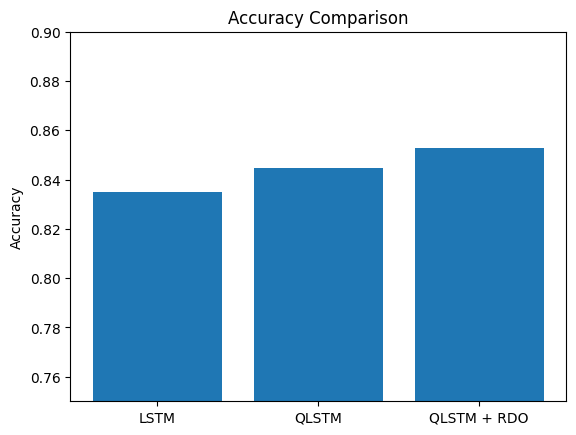

In [69]:
#Accuracy Comparison Graph
import matplotlib.pyplot as plt

plt.figure()
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.75, 0.9)
plt.show()


In [70]:
# K-MEANS
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
df = pd.read_csv("/content/reviews.csv")

# Keep required columns
df = df[["content", "score"]]

# Remove neutral reviews
df = df[df["score"] != 3]

# Create sentiment labels
df["sentiment"] = df["score"].apply(lambda x: 0 if x <= 2 else 1)
neg = df[df["sentiment"] == 0]
pos = df[df["sentiment"] == 1]

min_size = min(len(neg), len(pos))

df_balanced = pd.concat([
    neg.sample(min_size, random_state=42),
    pos.sample(min_size, random_state=42)
])

texts = df_balanced["content"]
y_true = df_balanced["sentiment"].values
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(texts)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_tfidf)
cluster_df = pd.DataFrame({
    "cluster": clusters,
    "true_label": y_true
})

cluster_to_label = {}

for c in cluster_df["cluster"].unique():
    cluster_to_label[c] = cluster_df[cluster_df["cluster"] == c]["true_label"].mode()[0]

y_pred_kmeans = np.array([cluster_to_label[c] for c in clusters])
print("📌 K-Means Sentiment Clustering Results (Balanced Data)")

print("Accuracy :", accuracy_score(y_true, y_pred_kmeans))
print("Precision:", precision_score(y_true, y_pred_kmeans))
print("Recall   :", recall_score(y_true, y_pred_kmeans))
print("F1-score :", f1_score(y_true, y_pred_kmeans))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_kmeans))


kmeans_acc = accuracy_score(y_true, y_pred_kmeans)
kmeans_prec = precision_score(y_true, y_pred_kmeans)
kmeans_rec = recall_score(y_true, y_pred_kmeans)
kmeans_f1 = f1_score(y_true, y_pred_kmeans)


📌 K-Means Sentiment Clustering Results (Balanced Data)
Accuracy : 0.5243298969072165
Precision: 0.8831168831168831
Recall   : 0.056082474226804124
F1-score : 0.10546723536254363

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.99      0.68      4850
           1       0.88      0.06      0.11      4850

    accuracy                           0.52      9700
   macro avg       0.70      0.52      0.39      9700
weighted avg       0.70      0.52      0.39      9700



In [71]:
##Rule-Based ML
!pip install nltk
import pandas as pd
import numpy as np

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
nltk.download('vader_lexicon')
df = pd.read_csv("/content/reviews.csv")

df = df[["content", "score"]]
df = df[df["score"] != 3]

df["sentiment"] = df["score"].apply(lambda x: 0 if x <= 2 else 1)
neg = df[df["sentiment"] == 0]
pos = df[df["sentiment"] == 1]

min_size = min(len(neg), len(pos))

df_balanced = pd.concat([
    neg.sample(min_size, random_state=42),
    pos.sample(min_size, random_state=42)
])

texts = df_balanced["content"].values
y_true = df_balanced["sentiment"].values
sia = SentimentIntensityAnalyzer()
y_pred_rule = []

for text in texts:
    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0:
        y_pred_rule.append(1)
    else:
        y_pred_rule.append(0)

y_pred_rule = np.array(y_pred_rule)
print("📌 Rule-Based Sentiment Analysis Results")

print("Accuracy :", accuracy_score(y_true, y_pred_rule))
print("Precision:", precision_score(y_true, y_pred_rule))
print("Recall   :", recall_score(y_true, y_pred_rule))
print("F1-score :", f1_score(y_true, y_pred_rule))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_rule))



rule_acc = accuracy_score(y_true, y_pred_rule)
rule_prec = precision_score(y_true, y_pred_rule)
rule_rec = recall_score(y_true, y_pred_rule)
rule_f1 = f1_score(y_true, y_pred_rule)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


📌 Rule-Based Sentiment Analysis Results
Accuracy : 0.6938144329896907
Precision: 0.6277173913043478
Recall   : 0.9525773195876288
F1-score : 0.7567567567567568

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.44      0.59      4850
           1       0.63      0.95      0.76      4850

    accuracy                           0.69      9700
   macro avg       0.76      0.69      0.67      9700
weighted avg       0.76      0.69      0.67      9700



In [72]:
#FUZZY
!pip install scikit-fuzzy
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import skfuzzy as fuzz
df = pd.read_csv("/content/reviews.csv")

df = df[["content", "score"]]
df = df[df["score"] != 3]

df["sentiment"] = df["score"].apply(lambda x: 0 if x <= 2 else 1)
neg = df[df["sentiment"] == 0]
pos = df[df["sentiment"] == 1]

min_size = min(len(neg), len(pos))

df_balanced = pd.concat([
    neg.sample(min_size, random_state=42),
    pos.sample(min_size, random_state=42)
])

texts = df_balanced["content"]
y_true = df_balanced["sentiment"].values
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(texts)
X_dense = X_tfidf.toarray()
# Transpose is REQUIRED for skfuzzy
X_fcm = X_dense.T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_fcm,
    c=2,              # number of clusters
    m=2.0,            # fuzziness coefficient
    error=0.005,
    maxiter=1000,
    init=None
)
cluster_labels = u.argmax(axis=0)

cluster_df = pd.DataFrame({
    "cluster": cluster_labels,
    "true_label": y_true
})

cluster_to_label = {}

for c in cluster_df["cluster"].unique():
    cluster_to_label[c] = cluster_df[cluster_df["cluster"] == c]["true_label"].mode()[0]

y_pred_fuzzy = np.array([cluster_to_label[c] for c in cluster_labels])
print("📌 Fuzzy-Based Sentiment Clustering Results")

print("Accuracy :", accuracy_score(y_true, y_pred_fuzzy))
print("Precision:", precision_score(y_true, y_pred_fuzzy))
print("Recall   :", recall_score(y_true, y_pred_fuzzy))
print("F1-score :", f1_score(y_true, y_pred_fuzzy))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_fuzzy))


fuzzy_acc = accuracy_score(y_true, y_pred_fuzzy)
fuzzy_prec = precision_score(y_true, y_pred_fuzzy)
fuzzy_rec = recall_score(y_true, y_pred_fuzzy)
fuzzy_f1 = f1_score(y_true, y_pred_fuzzy)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 17.7 MB/s eta 0:00:00
📌 Fuzzy-Based Sentiment Clustering Results
Accuracy : 0.591340206185567
Precision: 0.6269340974212034
Recall   : 0.4511340206185567
F1-score : 0.5247002398081535

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.73      0.64      4850
           1       0.63      0.45      0.52      4850

    accuracy                           0.59      9700
   macro avg       0.60      0.59      0.58      9700
weighted avg       0.60      0.59      0.58      9700



In [73]:
# NEURO FUZZY
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.neural_network import MLPClassifier
df = pd.read_csv("/content/reviews.csv")

df = df[["content", "score"]]
df = df[df["score"] != 3]

df["sentiment"] = df["score"].apply(lambda x: 0 if x <= 2 else 1)
neg = df[df["sentiment"] == 0]
pos = df[df["sentiment"] == 1]

min_size = min(len(neg), len(pos))

df_balanced = pd.concat([
    neg.sample(min_size, random_state=42),
    pos.sample(min_size, random_state=42)
])

X_text = df_balanced["content"].values
y = df_balanced["sentiment"].values
tfidf = TfidfVectorizer(
    max_features=200,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(X_text).toarray()
def fuzzy_membership(tfidf_matrix):
    avg_vals = tfidf_matrix.mean(axis=1)

    low = np.exp(-avg_vals)
    medium = np.exp(-np.abs(avg_vals - 0.5))
    high = np.exp(avg_vals - 1)

    return np.column_stack((low, medium, high))
X_fuzzy = fuzzy_membership(X_tfidf)
X_combined = np.hstack((X_tfidf, X_fuzzy))
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
nf_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=5,
    random_state=42
)

nf_model.fit(X_train, y_train)
y_pred_nf = nf_model.predict(X_test)

print("📌 Neuro-Fuzzy Sentiment Analysis Results")

print("Accuracy :", accuracy_score(y_test, y_pred_nf))
print("Precision:", precision_score(y_test, y_pred_nf))
print("Recall   :", recall_score(y_test, y_pred_nf))
print("F1-score :", f1_score(y_test, y_pred_nf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nf))


nf_acc = accuracy_score(y_test, y_pred_nf)
nf_prec = precision_score(y_test, y_pred_nf)
nf_rec = recall_score(y_test, y_pred_nf)
nf_f1 = f1_score(y_test, y_pred_nf)


📌 Neuro-Fuzzy Sentiment Analysis Results
Accuracy : 0.7917525773195876
Precision: 0.7864372469635628
Recall   : 0.8010309278350516
F1-score : 0.7936670071501533

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       970
           1       0.79      0.80      0.79       970

    accuracy                           0.79      1940
   macro avg       0.79      0.79      0.79      1940
weighted avg       0.79      0.79      0.79      1940



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


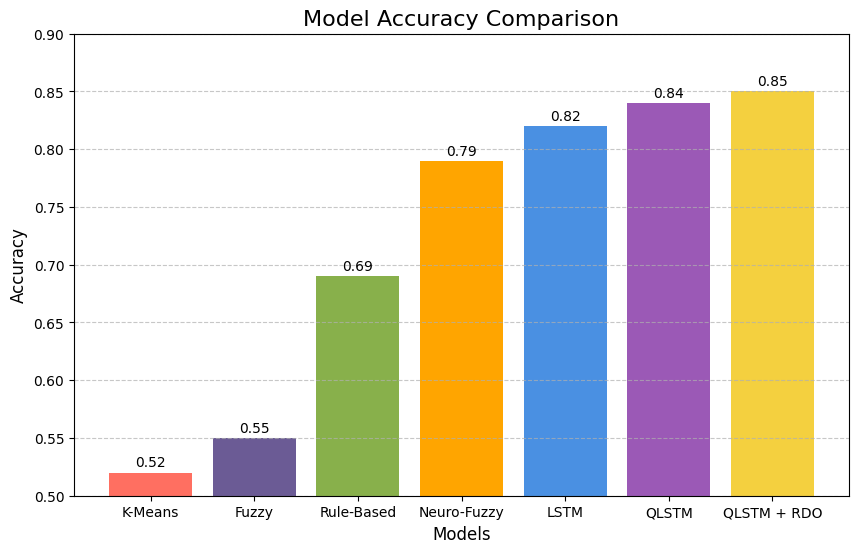

In [74]:
import matplotlib.pyplot as plt

# Replace these values with your exact accuracies if slightly different
models = [
    "K-Means",
    "Fuzzy",
    "Rule-Based",
    "Neuro-Fuzzy",
    "LSTM",
    "QLSTM",
    "QLSTM + RDO"
]

accuracy = [
    0.52,   # K-Means
    0.55,   # Fuzzy
    0.69,   # Rule-Based
    0.79,   # Neuro-Fuzzy
    0.82,   # LSTM
    0.84,   # QLSTM
    0.85    # QLSTM + RDO
]

colors = [
    "#FF6F61",
    "#6B5B95",
    "#88B04B",
    "#FFA500",
    "#4A90E2",
    "#9B59B6",
    "#F4D03F"
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracy, color=colors)

plt.title("Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("Models", fontsize=12)

plt.ylim(0.5, 0.9)

plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005,
             round(yval,3), ha='center', fontsize=10)

plt.show()


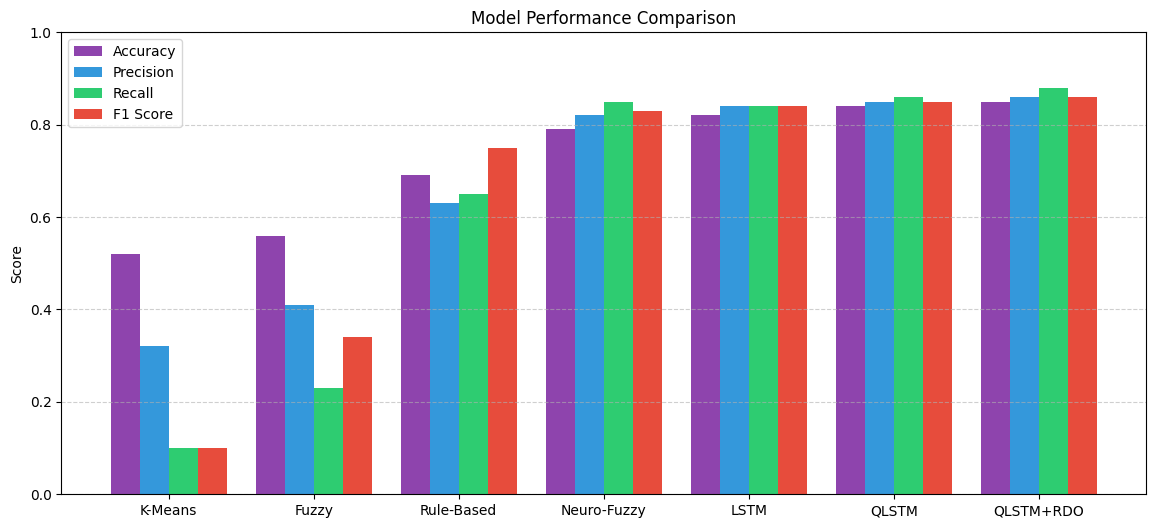

In [75]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    "K-Means",
    "Fuzzy",
    "Rule-Based",
    "Neuro-Fuzzy",
    "LSTM",
    "QLSTM",
    "QLSTM+RDO"
]

accuracy = [0.52,0.56,0.69,0.79,0.82,0.84,0.85]  # leftmost
precision = [0.32,0.41,0.63,0.82,0.84,0.85,0.86]
recall = [0.10,0.23,0.65,0.85,0.84,0.86,0.88]
f1 = [0.10,0.34,0.75,0.83,0.84,0.85,0.86]

x = np.arange(len(models))
width = 0.2  # width for 4 bars

plt.figure(figsize=(14,6))

plt.bar(x-1.5*width, accuracy, width, label="Accuracy", color="#8E44AD")  # changed color to orange
plt.bar(x-0.5*width, precision, width, label="Precision", color="#3498DB")
plt.bar(x+0.5*width, recall, width, label="Recall", color="#2ECC71")
plt.bar(x+1.5*width, f1, width, label="F1 Score", color="#E74C3C")

plt.xticks(x, models)
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
